# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 07: MLP e CNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_07_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [44]:
!pip install tensorflow numpy matplotlib seaborn scikit-learn

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [46]:
# Carregando o dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Ajustando dimensões dos rótulos
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Separando validação do treino
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Classes do dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

### <font color='#2D9CDB'>Q1) O dataset CIFAR-10 é amplamente utilizado em problemas de visão computacional e classificação de imagens. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o tipo de imagens que ela contém, a quantidade de classes existentes e alguns exemplos de objetos presentes nas imagens.</font>

O dataset consiste em 60000 imagens coloridas divididas em 10 classes, com 6000 imagens por classe. Seu domínio de aplicação é o reconhecimento de objetos e a classicação de imagens. O objetivo principal é servir como padrão de teste para o desenvolvimento de algoritmos de visão computacional. Cada imagem apresenta somente 32 x 32 pixels, são coloridas e utilizam o padrão de 8 bits por canal (valores variam de 0 a 255). Alguns exemplos de classes são: automóveis, gatos, cavalos, caminhões, etc...

### <font color='#2D9CDB'>Q2) Exiba as dimensões dos conjuntos de treinamento, validação e teste, o formato das imagens, as dimensões dos vetores de rótulos e os valores únicos da variável alvo. Com base nos resultados obtidos, responda quantas imagens existem nos conjuntos de treinamento, validação e teste, qual é a resolução das imagens, quantos canais cada imagem possui e quantas classes diferentes existem no dataset.</font>

In [47]:
display(x_train.shape, x_val.shape, x_test.shape)
num_classes = len(class_names) # ou num_classes = len(np.unique(y_test))
print(f'Número de classes (dimensões dos vetores de rótulo): {num_classes}')
print(f'Valores únicos da variável alvo: {np.unique(y_train)}')


(40000, 32, 32, 3)

(10000, 32, 32, 3)

(10000, 32, 32, 3)

Número de classes (dimensões dos vetores de rótulo): 10
Valores únicos da variável alvo: [0 1 2 3 4 5 6 7 8 9]


Há 40000 imagens no conjunto de treinamento, 10000 no de validação e 10000 no de teste. A resolução das imagens é 32 x 32 pixels. Cada imagem possui 3 canais. Existem 10 classes ao total no dataset.

### <font color='#2D9CDB'>Q3) Plote as primeiras 25 imagens do conjunto de treinamento utilizando a função imshow, exibindo também o nome da classe correspondente a cada imagem. Organize as imagens em uma grade 5×5 e remova os eixos para melhorar a visualização. Em seguida, analise visualmente o dataset e discuta se as imagens parecem simples ou complexas para classificação, quais características tornam o problema mais desafiador e se existem classes visualmente semelhantes.</font>

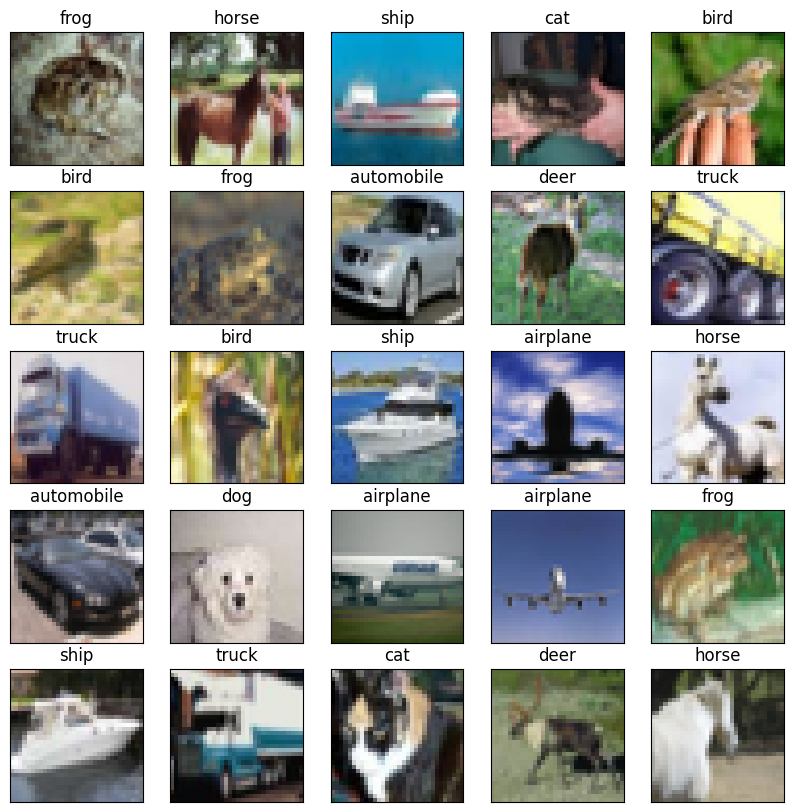

In [48]:
plt.figure(figsize=(10, 10))
for img in range(25):
  plt.subplot(5, 5, img+1)
  plt.title(class_names[y_train[img]])
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[:25][img])

Pela resolução baixa das imagens (1024 pixels totais), a complexidade é simples, mas vale considerar que para esta baixa resolução, alguns detalhes cruciais se perdem, o que aumenta a complexidade de análise. Desafios: ruído (qualquer variação mínima nos pixels pode 'confundir' o modelo; posição e oclusão visual (objetos podem estar cortados, de cabeça para baixo ou parcialmente escondidos), entre outros. Existem alguns pares de classes que podem confundir o modelo, como pássaros e aviões (vide imagem 19 desta questão) que podem gerar falsos positivos.

### <font color='#2D9CDB'>Q4) Plote a distribuição das classes do conjunto de treinamento utilizando um gráfico de barras. Com base no gráfico obtido, analise se o dataset é balanceado ou desbalanceado, compare a quantidade de amostras entre as classes e discuta se o balanceamento das classes pode impactar o treinamento e o desempenho de uma rede neural.</font>

In [49]:
import pandas as pd

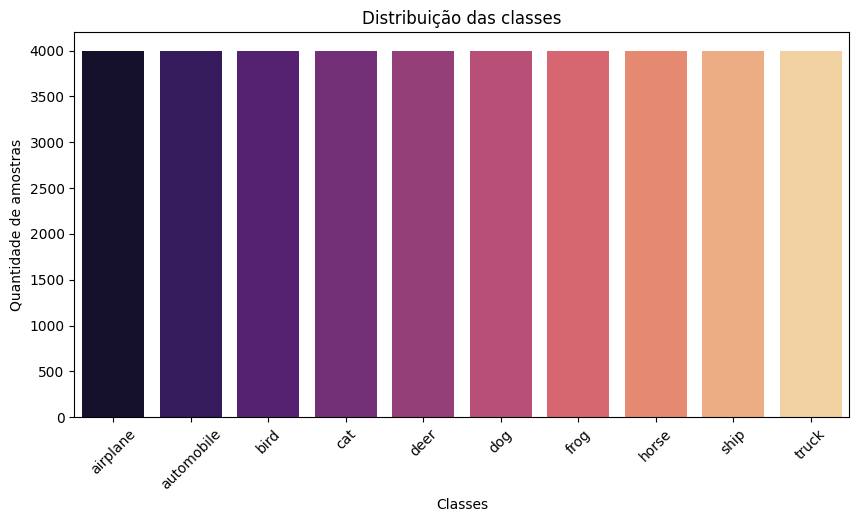

In [50]:
plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=pd.Series(y_train).value_counts(), palette='magma', hue=class_names)
plt.xticks(rotation=45)
plt.xlabel('Classes')
plt.ylabel('Quantidade de amostras')
plt.title('Distribuição das classes')
plt.show()

O dataset é totalmente balanceado, uma vez que todas as classes possuem igual número de amostras. Isso impacta positivamente no treinamento e no desempenho de uma rede neural, isso porque se uma classe tivesse uma quantidade muito maior que outra, a predição cairia consideravelmente, ao passo que o modelo provavelmente iria 'chutar' de forma incorreta.

### <font color='#2D9CDB'>Q5) Verifique os valores mínimo e máximo dos pixels das imagens do conjunto de treinamento. Em seguida, normalize os conjuntos de treino, validação e teste dividindo os valores dos pixels por 255. Após a normalização, verifique novamente os valores mínimo e máximo e explique por que esse procedimento é importante para o treinamento de redes neurais profundas. Discuta também como a normalização influencia a estabilidade numérica do treinamento e a velocidade de convergência do algoritmo de otimização.</font>

In [51]:
print(f'Valores mínimo e máximo antes da normalização: {x_train.min()}, {x_train.max()}')

x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

print(f'Valores mínimo e máximo após a normalização: {x_train.min()}, {x_train.max()}')


Valores mínimo e máximo antes da normalização: 0, 255
Valores mínimo e máximo após a normalização: 0.0, 1.0


A normalização é importante para garantir que variáveis não dominem o aprendizado (escalas muito diferentes), para acelerar a convergência do gradiente descendente e para reduzir problemas de explosão do gradiente ou desaparecimento. Por diminuir o limite dos valores a um certo intervalo, a normalização evita cálculos que geram valores extremos e otimizam a velocidade de convergência do algoritmo de otimização ao evitar que muitas iterações sejam necessárias para convergência, ao garantir passos mais diretos.

### <font color='#2D9CDB'>Q6) Explique por que as imagens do CIFAR-10 podem ser representadas como tensores tridimensionais. Em seguida, identifique o significado de cada dimensão do tensor (32, 32, 3), explique o papel dos canais RGB e discuta a diferença entre imagens coloridas e imagens em tons de cinza no contexto de redes neurais convolucionais.</font>

As imagens podem ser representadas como tensores tridimensionais porque podem ser representadas em (altura x largura x canais de cor). Significado de cada dimensão: (32 - representa a quantidade de pixels da altura, 32 - representa a quantidade de pixels da largura, 3 - representa os canais de cores RGB).Os canais RGB são responsáveis pela coloração da imagem, sendo dividido em R (vermelho), G (verde) e B (azul). A principal diferença se encontra na profundidade dos filtros (kernels), que para imagens em tons de cinza é uma matriz 2D, enquanto que para imagens coloridas, o filtro é uma matriz 3D. Dessa forma, a complexidade de trabalhar com imagens coloridas é muito maior do que imagens em tons de cinza.

# <font color='green'><u><b>Parte 2 - MLP</b></u></font>

### <font color='#2D9CDB'>Q7) As redes neurais do tipo Multilayer Perceptron (MLP) utilizam camadas densamente conectadas e, portanto, esperam vetores unidimensionais como entrada. Explique por que é necessário transformar as imagens do CIFAR-10 antes de utilizá-las em uma MLP e discuta o que acontece com a estrutura espacial das imagens durante esse processo. Em seguida, construa uma rede neural MLP utilizando a API Sequential do Keras com uma camada Flatten, duas camadas densas escondidas com função de ativação ReLU e uma camada de saída com 10 neurônios e ativação Softmax.</font>

In [52]:
from tensorflow import keras as kf
from tensorflow.keras import layers

In [53]:
model = kf.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)


A MLP espera como entrada um único vetor unidimensional, sendo necessário a transformação para que cada pixel se torne uma feature de entrada para os neurônios (flatten). Ao transformar a imagem em um vetor, ocorre perda total da estrutura espacial, tratando a imagem como uma lista aleatória de números ao invés de um arranjo visual estruturado.

### <font color='#2D9CDB'>Q8) Exiba o resumo da arquitetura da rede neural criada utilizando o método summary() e analise a quantidade de parâmetros treináveis da MLP. Com base nas dimensões das imagens do CIFAR-10 e no número de neurônios utilizados nas camadas densas, discuta por que MLPs podem rapidamente se tornar modelos muito grandes para problemas de classificação de imagens.</font>

In [54]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

O problema aparece para quantidade de neurônios e quantidade de camadas: a quantidade de parâmetros cresce muito com o aumento do número dessas duas propriedades, fazendo com que o modelo possa ficar extremamente complexo e pesado para problemas de classificação.

### <font color='#2D9CDB'>Q9) Compile a MLP utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, explique o papel da função de custo durante o treinamento, o objetivo do algoritmo de otimização e por que a combinação entre Softmax e entropia cruzada é adequada para problemas de classificação multiclasse.</font>

In [55]:
model.compile(
    optimizer=kf.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

A função da entropia cruzada categórica é usada pra treinar modelos de classificação multiclasse. Ela mede a diferença entre a distribuição de probabilidade prevista pelo modelo e a distribuição real. O objetivo do otimizador é ajustar os pesos da rede neural de forma eficiente para minimizar o erro durante o treinamento. A combinação entre Softmax e Entropia Cruzada é adequada porque a função softmax transforma as saídas da rede em probabilidades, enquanto a entropia cruzada utiliza essas probabilidades com as diferenças já citadas, penalizando previsões incorretas.

### <font color='#2D9CDB'>Q10) Treine a rede neural por 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History e, em seguida, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação. Após gerar os gráficos, analise o comportamento do treinamento, discutindo se o modelo aparenta convergir adequadamente, se há estabilidade durante o treinamento e se existem indícios de overfitting.</font>

In [56]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=32
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.3210 - loss: 1.8748 - val_accuracy: 0.3494 - val_loss: 1.7996
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3869 - loss: 1.7011 - val_accuracy: 0.3955 - val_loss: 1.6830
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4194 - loss: 1.6248 - val_accuracy: 0.3988 - val_loss: 1.6928
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4355 - loss: 1.5742 - val_accuracy: 0.4177 - val_loss: 1.6373
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4481 - loss: 1.5384 - val_accuracy: 0.4292 - val_loss: 1.6111
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4600 - loss: 1.5073 - val_accuracy: 0.4429 - val_loss: 1.5806
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4691 - loss: 1.4832 - val_accuracy: 0.4363 - val_loss: 1.6040
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4747 - loss: 1.4626 -

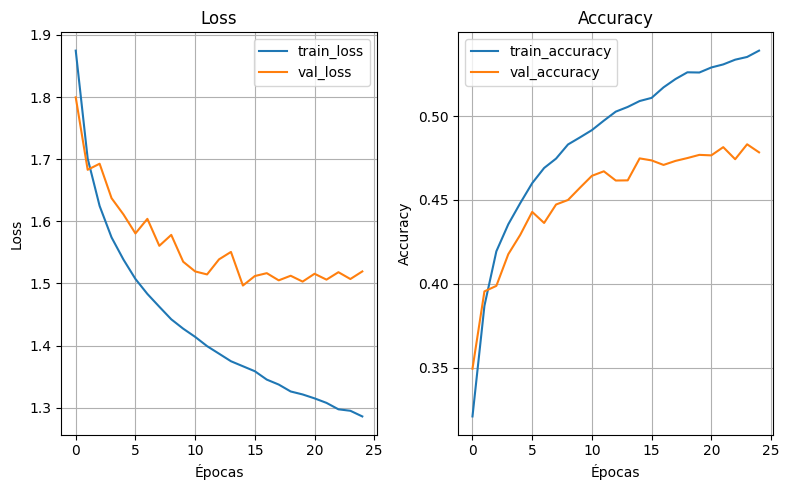

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))

# Loss
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.plot(history.history['loss'], label='train_loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()
ax1.grid()

# Accuracy
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.plot(history.history['accuracy'], label='train_accuracy')
ax2.plot(history.history['val_accuracy'], label='val_accuracy')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


O modelo converge, mas de forma assimétrica (enquanto train_loss cai continuamente, val_loss cai rapidamente, mas estabiliza). O treinamento é estável, mas apresenta indícios de overfitting moderado - a partir da época 10, train_loss se estabiliza, o que indica que a generalização estagnou nesse momento, mas como train_loss continua caindo, demonstra-se a memorização de parte dos dados de treinamento.

### <font color='#2D9CDB'>Q11) Avalie o desempenho da MLP utilizando o conjunto de teste e reporte os valores de loss e accuracy obtidos. Em seguida, compare os resultados dos conjuntos de treinamento e teste e discuta se o modelo aparenta apresentar boa capacidade de generalização.</font>

In [58]:
train_loss, train_accuracy = model.evaluate(x_train, y_train)

print(f'Loss no conjunto de treinamento: {train_loss}')
print(f'Accuracy no conjunto de treinamento: {train_accuracy}')

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f'Loss no conjunto de teste: {test_loss}')
print(f'Accuracy no conjunto de teste: {test_accuracy}')

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5408 - loss: 1.2745
Loss no conjunto de treinamento: 1.2745379209518433
Accuracy no conjunto de treinamento: 0.5408250093460083
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4829 - loss: 1.5012
Loss no conjunto de teste: 1.501184105873108
Accuracy no conjunto de teste: 0.4828999936580658


O modelo claramente aprendeu padrões do treino que não transferem completamente para dados novos (overfitting moderado).

### <font color='#2D9CDB'>Q12) Utilize a MLP treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita pelo modelo e compare-a com a classe verdadeira da imagem. Com base nas probabilidades obtidas, explique o significado da saída Softmax e discuta se o modelo está realizando previsões com alta ou baixa confiança.</font>

In [59]:
prediction = model.predict(x_test[:9])
y_pred_class = np.argmax(prediction, axis=1)
print(f'Classes previstas: {y_pred_class}')
print(f'Classes verdadeiras: {y_test[:9]}')

print('-'*100)
print(f'Probabilidades: {prediction}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Classes previstas: [3 9 8 0 4 6 5 6 3]
Classes verdadeiras: [3 8 8 0 6 6 1 6 3]
----------------------------------------------------------------------------------------------------
Probabilidades: [[3.82917677e-03 1.78303514e-02 4.03509997e-02 5.49012959e-01
  9.16572884e-02 2.00642660e-01 4.19148915e-02 2.46063550e-03
  4.48125899e-02 7.48840766e-03]
 [3.63184065e-02 2.16024667e-01 1.22177953e-04 1.19339220e-05
  2.15505890e-04 3.23615086e-06 9.75587591e-06 1.27129681e-06
  2.21373007e-01 5.25920093e-01]
 [2.81227529e-01 1.38761014e-01 6.39637816e-04 7.56725203e-04
  4.97519737e-03 3.77820834e-04 2.03138006e-06 1.07491016e-02
  4.88420129e-01 7.40907863e-02]
 [3.06374401e-01 1.09081618e-01 5.18731736e-02 3.72901782e-02
  5.50784990e-02 2.45779138e-02 6.12609729e-04 1.01830341e-01
  2.71159649e-01 4.21217121e-02]
 [6.27510715e-04 2.64530099e-04 1.03975706e-01 4.36825529e-02
  5.38455188e-01 2.10775323e-02 2.84941971e-01 4.33329027e-03
  2.34763650

Analisando as probabilidades, nota-se que o modelo está tendo dificuldades na classificação das imagens ao ter uma acurácia de apenas 55%. A função Softmax transforma a saída da rede em um vetor de probabilidades que soma exatamente 1. Olhando para os seus dados, o modelo apresenta, em sua maioria, baixa confiança e sinais de incerteza severa, isso porque mesmo para as amostras que o modelo acertou, a probabilidade não é muito alta.

### <font color='#2D9CDB'>Q13) Plote a matriz de confusão da MLP utilizando o conjunto de teste. Em seguida, identifique quais classes foram mais confundidas pelo modelo e discuta possíveis razões para esses erros de classificação, considerando as limitações de uma arquitetura MLP aplicada a problemas de visão computacional.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


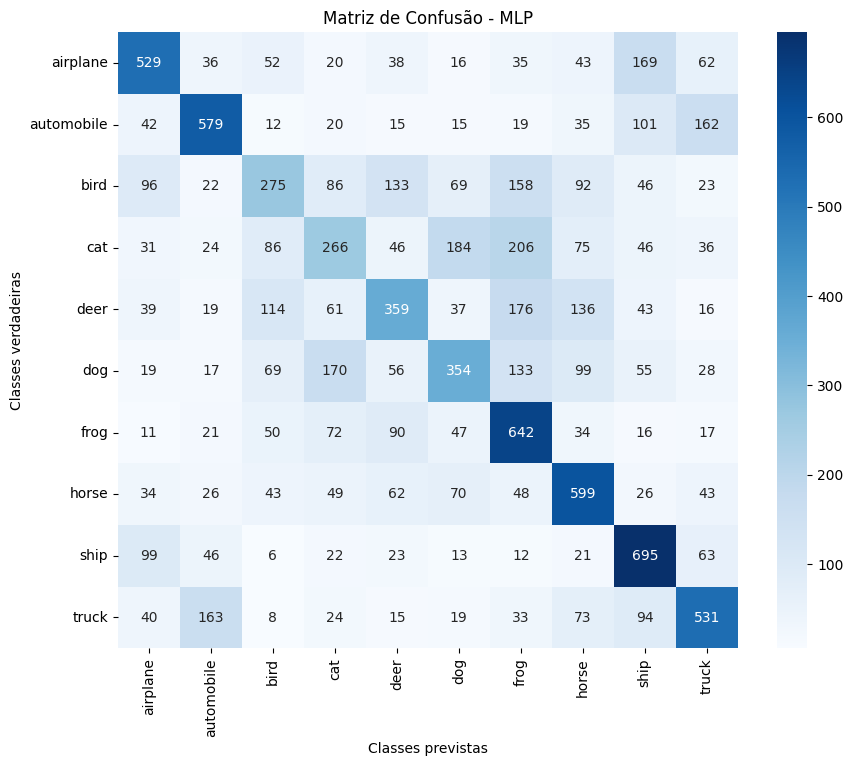

In [60]:
prediction_full = model.predict(x_test)
y_pred_class_full = np.argmax(prediction_full, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_class_full)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Classes previstas')
plt.ylabel('Classes verdadeiras')
plt.title('Matriz de Confusão - MLP')
plt.show()

In [61]:
# Classes mais confundidas

print(np.array(class_names)[np.argsort(conf_matrix.diagonal())[:4]])


['cat' 'bird' 'dog' 'deer']


As classes mais confundidas foram cervo, cachorro, pássaro e gato.

Em uma MLP, as sutis diferenças entre um "gato" e um "cachorro" em apenas 32 pixels são diluídas no meio de tantos pesos. Sem filtros convolucionais para extrair características hierárquicas (primeiro bordas, depois formas, depois partes do corpo), a MLP tenta fazer tudo de uma vez, resultando em classificações baseadas mais na cor predominante do que na forma do objeto.

### <font color='#2D9CDB'>Q14) Com base nos resultados obtidos ao longo desta etapa, discuta as principais vantagens e limitações das redes MLP para classificação de imagens. Em sua resposta, considere aspectos como preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização e desempenho obtido no CIFAR-10.</font>

As MLPs não preservam a estrutura espacial em razão da alimentação por um vetor unidimensional. Elas são redes densamente conectadas, o que gera uma explosão de parâmetros. A capacidade de generalização das MLPs para imagens é baixa, pois ela aprende padrões fixos em posições fixas dos pixels, baseando-se exatamente nas posições e cores dos objetos. No contexto do CIFAR-10, as MLPs entregam um desempenho limitado, tendo como única vantagem a simplicidade de implementação para problemas de baixa dimensionalidade ou dados tabulares.

# <font color='green'><u><b>Parte 3 - CNN</b></u></font>

### <font color='#2D9CDB'>Q15) As redes neurais convolucionais (CNNs) foram desenvolvidas para lidar melhor com dados que possuem estrutura espacial, como imagens. Explique por que arquiteturas MLP apresentam limitações em problemas de visão computacional e descreva como as CNNs conseguem preservar relações espaciais entre os pixels. Em seguida, explique os conceitos de convolução, filtros convolucionais e mapas de características (feature maps).</font>

As MLPs sofrem basicamente de dois problemas principais: perda de contexto local (ao transformar a imagem em um vetor unidimensional, a MLP ignora a proximidade entre os pixels) e imprecisão de aprendizado por áreas da imagem (padrões iguais em áreas diferentes não são bem reconhecidos por estas redes).

Diferentemente das MLPs, as CNNs utilizam conectividade local - cada neurônio em uma camada convolucional se conecta apenas a uma região pequena da imagem de entrada, garantindo que as relações de vizinhança entre os pixels sejam preservadas.

A convolução é uma operação matemática onde uma matriz de pesos 'desliza' sobre a imagem, sendo essencial na busca por padrões específicos.

Os filtros convolucionais (kernels) são matrizes pequenas que aprendem a detectar uma feature específica.

O mapa de características é o resultado da aplicação do filtro sobre a imagem onde certas características visuais foram encontradas.

### <font color='#2D9CDB'>Q16) Construa uma rede neural convolucional utilizando a API Sequential do Keras. A arquitetura da CNN deve conter camadas Conv2D com ativação ReLU, camadas MaxPooling2D, uma camada Flatten e uma camada de saída com 10 neurônios e ativação Softmax. Após construir a arquitetura, explique o papel das camadas convolucionais, das camadas de pooling e da camada Flatten dentro da CNN.</font>

In [62]:
model = kf.Sequential([

    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])

As camadas convolucionais são essenciais para as CNNs ao extrair características importantes da imagem (bordas, texturas, formas) - processo de criação dos mapas de características. A camada de Pooling é responsável por selecionar um valor específico de uma pequena região do mapa de características, descartando o restante - relevante para redução de dimensionalidade. A camada Flatten achata a estrutura das matrizes em vetores para que uma camada densa possa fazer a classificação final.

### <font color='#2D9CDB'>Q17) Exiba o resumo da arquitetura da CNN utilizando o método summary() e compare a quantidade de parâmetros treináveis da CNN com a da MLP construída anteriormente. Em seguida, discuta por que CNNs costumam ser mais eficientes para classificação de imagens, mesmo utilizando menos parâmetros treináveis.</font>

In [63]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

A quantidade de parâmetros treináveis reduziu drasticamente em relação à MLP.

As CNNs costumam ser mais eficientes para classificação de imagens do que MLPs em razão da estrutura delas. Elas garantem que o modelo aprenda conceitos visuais complexos com uma fração da memória necessária para um rede comum, principalmente ao explorar a correlação local.

### <font color='#2D9CDB'>Q18) Compile a CNN utilizando o otimizador Adam com taxa de aprendizado de $10^{-3}$, a função de custo sparse_categorical_crossentropy e a métrica accuracy. Em seguida, treine o modelo por até 25 épocas utilizando os conjuntos de treinamento e validação. Armazene o histórico do treinamento em um objeto do tipo History. Após o treinamento, plote gráficos mostrando a evolução da loss e da accuracy ao longo das épocas para os conjuntos de treinamento e validação e analise o comportamento do treinamento da CNN.</font>

In [64]:
model.compile(
    optimizer=kf.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=32
)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4597 - loss: 1.5110 - val_accuracy: 0.5656 - val_loss: 1.2492
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5924 - loss: 1.1739 - val_accuracy: 0.6248 - val_loss: 1.1052
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6380 - loss: 1.0484 - val_accuracy: 0.6541 - val_loss: 1.0281
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6679 - loss: 0.9651 - val_accuracy: 0.6653 - val_loss: 0.9896
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6909 - loss: 0.9033 - val_accuracy: 0.6718 - val_loss: 0.9755
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7090 - loss: 0.8542 - val_accuracy: 0.6766 - val_loss: 0.9683
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7227 - loss: 0.8122 - val_accuracy: 0.6776 - val_loss: 0.9686
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7351 - loss: 0.7752 - 

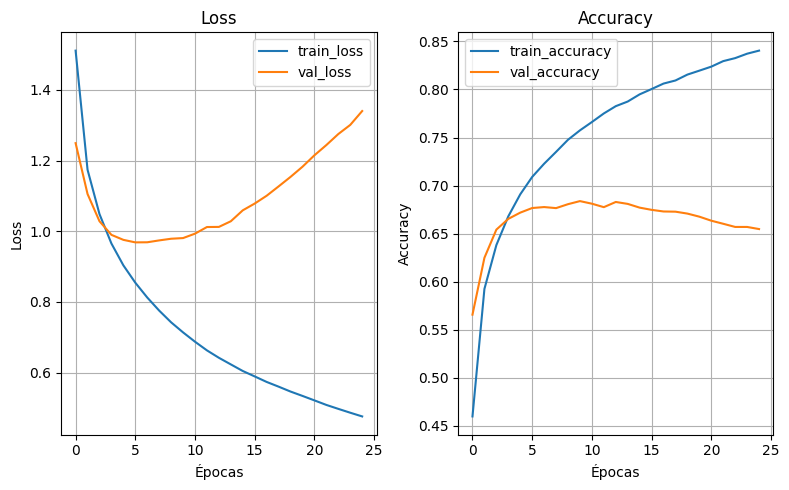

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))

# Loss
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.plot(history.history['loss'], label='train_loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()
ax1.grid()

# Accuracy
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.plot(history.history['accuracy'], label='train_accuracy')
ax2.plot(history.history['val_accuracy'], label='val_accuracy')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

Analisando os gráficos, o modelo parece estar sofrendo um overfitting: train_loss continua descendo, o que mostra que o modelo está aprendendo a "decorar" os dados de treino, visualizando que val_loss aumenta - indício de perda de capacidade de generalização.

### <font color='#2D9CDB'>Q19) Avalie o desempenho da CNN utilizando o conjunto de teste e compare os resultados obtidos com aqueles alcançados pela MLP. Em seguida, discuta as diferenças observadas em termos de accuracy, capacidade de generalização e aprendizado de características visuais.</font>

In [66]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f'Loss no conjunto de teste: {test_loss}')
print(f'Accuracy no conjunto de teste: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6599 - loss: 1.3079
Loss no conjunto de teste: 1.3079355955123901
Accuracy no conjunto de teste: 0.6599000096321106


Apesar do overfitting observado, a CNN alcançou uma acurácia maior na classificação das imagens do dataset (66% contra 47%). A capacidade de generalização da CNN foi maior, assim como o aprendizado de características visuais.

### <font color='#2D9CDB'>Q20) Utilize a CNN treinada para gerar previsões sobre algumas imagens do conjunto de teste. Exiba as probabilidades previstas para cada classe, identifique a classe predita e compare-a com a classe verdadeira da imagem. Em seguida, analise se a CNN aparenta realizar previsões mais confiantes que a MLP e discuta possíveis razões para esse comportamento.</font>

In [67]:
prediction = model.predict(x_test[:9])
y_pred_class = np.argmax(prediction, axis=1)
print(f'Classes previstas: {y_pred_class}')
print(f'Classes verdadeiras: {y_test[:9]}')

print('-'*100)
print(f'Probabilidades: {prediction}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Classes previstas: [3 8 8 0 6 6 1 6 3]
Classes verdadeiras: [3 8 8 0 6 6 1 6 3]
----------------------------------------------------------------------------------------------------
Probabilidades: [[1.25074628e-04 7.46669139e-06 2.11982187e-04 7.37114668e-01
  3.39310782e-06 2.60623634e-01 1.61007524e-03 1.68952283e-08
  2.99098640e-04 4.56501539e-06]
 [1.84662909e-07 1.16806099e-04 1.70530950e-10 2.90528235e-13
  9.81183273e-16 2.44824302e-17 1.96025195e-17 1.85891585e-13
  9.99882936e-01 2.12877982e-09]
 [2.16541603e-01 7.16499472e-03 2.95542213e-05 4.90342463e-05
  5.86066628e-04 1.36989945e-06 9.44498346e-09 1.41847820e-04
  7.75132358e-01 3.53127078e-04]
 [9.87254381e-01 7.32751505e-04 4.68973012e-04 2.64482132e-05
  7.59520044e-04 6.34284447e-08 4.83290430e-09 2.22123845e-07
  1.07570514e-02 3.48167788e-07]
 [1.20857241e-10 4.15070417e-06 5.87833383e-05 9.87867452e-03
  4.46145624e-01 2.34099396e-04 5.43672621e-01 2.41635565e-08
  5.97000189

A CNN realiza previsões mais confiantes que a MLP, pois algumas classes daquela, possuíram valores mais próximos de 1 (maior confiança) que as classes da MLP. A CNN é mais confiável pois ela "enxerga" estruturas e formas, enquanto outras redes (como as MLPs) apenas "leem" valores numéricos de pixels sem entender a relação espacial entre eles.

### <font color='#2D9CDB'>Q21) Plote a matriz de confusão da CNN utilizando o conjunto de teste e compare-a com a matriz de confusão obtida pela MLP. Identifique quais classes apresentaram melhora significativa de classificação e discuta por que CNNs conseguem reduzir confusões entre classes visualmente semelhantes.</font>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


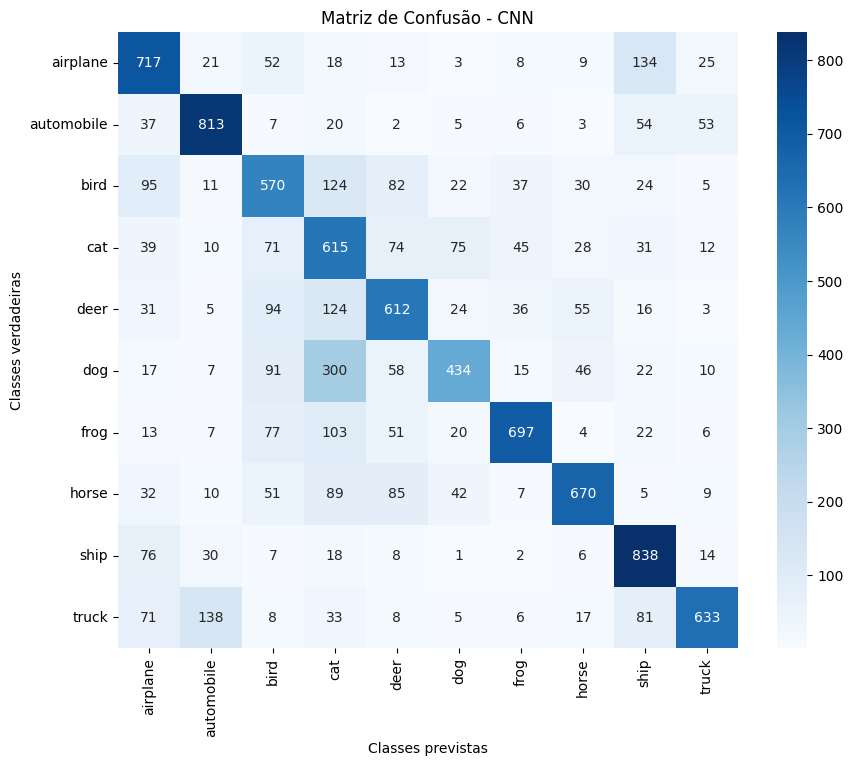

In [68]:
prediction_full = model.predict(x_test)
y_pred_class_full = np.argmax(prediction_full, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_class_full)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Classes previstas')
plt.ylabel('Classes verdadeiras')
plt.title('Matriz de Confusão - CNN')
plt.show()

Comparando com a matriz de confusão da MLP, houve maior acertividade por parte do modelo usando CNN (valores maiores na diagonal principal). As classes com melhora significativa foram: caminhão, navio, cervo e cavalo. A CNN consegue lidar bem com misturas mosfológicas devido à sua estrutura específica de detecção de texturas e redução de ruído.

### <font color='#2D9CDB'>Q22) Adicione camadas Dropout à CNN e treine novamente o modelo. Em seguida, plote as curvas de loss e accuracy para os conjuntos de treinamento e validação e compare os resultados com a CNN original. Com base nos gráficos obtidos, discuta o impacto do Dropout no overfitting e na capacidade de generalização da rede neural.</font>

In [69]:
model_dropout = kf.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_dropout.compile(
    optimizer=kf.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_dropout.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=32
)



Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3787 - loss: 1.7018 - val_accuracy: 0.5127 - val_loss: 1.3958
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4938 - loss: 1.4110 - val_accuracy: 0.5619 - val_loss: 1.2756
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5330 - loss: 1.3164 - val_accuracy: 0.6039 - val_loss: 1.1674
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5552 - loss: 1.2507 - val_accuracy: 0.6238 - val_loss: 1.1232
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5722 - loss: 1.2100 - val_accuracy: 0.6436 - val_loss: 1.0798
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5865 - loss: 1.1772 - val_accuracy: 0.6488 - val_loss: 1.0578
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5913 - loss: 1.1593 - val_accuracy: 0.6592 - val_loss: 1.0223
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6036 - loss: 1.1318 -

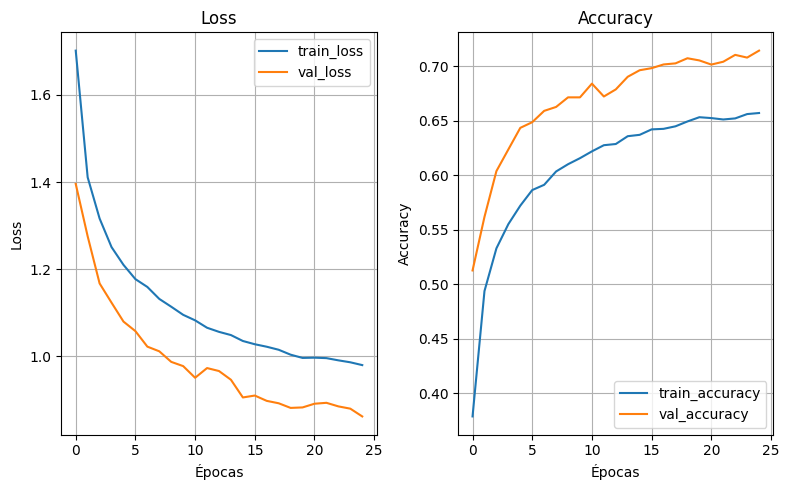

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))

# Loss
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.plot(history.history['loss'], label='train_loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()
ax1.grid()

# Accuracy
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.plot(history.history['accuracy'], label='train_accuracy')
ax2.plot(history.history['val_accuracy'], label='val_accuracy')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

A adição de camadas Dropout à CNN mitigou drasticamente o overfitting observado no modelo original, onde a perda de validação divergia precocemente da perda de treinamento. Ao desativar aleatoriamente neurônios durante o treino, a rede foi impedida de memorizar ruídos específicos do conjunto de dados, resultando em curvas de aprendizado muito mais estáveis e convergentes. Como consequência, a capacidade de generalização aumentou significativamente, permitindo que a acurácia de validação superasse a de treinamento e atingisse patamares mais elevados do que os da arquitetura original, provando que o modelo se tornou mais robusto para classificar imagens inéditas.

### <font color='#2D9CDB'>Q23) Com base em todos os resultados obtidos ao longo da atividade, compare as arquiteturas MLP e CNN para classificação de imagens. Em sua resposta, discuta diferenças relacionadas à preservação da estrutura espacial das imagens, quantidade de parâmetros treináveis, capacidade de generalização, desempenho obtido no CIFAR-10 e adequação de cada arquitetura para problemas de visão computacional.</font>

Ao comparar as arquiteturas no CIFAR-10, observa-se que a CNN supera amplamente a MLP em tarefas de visão computacional por preservar a estrutura espacial e as relações locais entre pixels por meio de filtros convolucionais e camadas de pooling. Enquanto a MLP sofre com uma explosão de parâmetros e baixa generalização por tratar a imagem como um vetor desordenado, a CNN utiliza o compartilhamento de pesos para aprender características hierárquicas de forma eficiente, resultando em matrizes de confusão com diagonais muito mais definidas e maior robustez contra translações. Mesmo que o treinamento da CNN possa ser mais lento por época e propenso ao overfitting se não houver regularização, sua capacidade de distinguir classes visualmente semelhantes através de padrões morfológicos a torna o padrão para o reconhecimento de imagens.